In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import json, os, joblib, math, ast, random
from itertools import product

In [54]:
def loadBackup(base):
    df = []

    for path in os.listdir(base):
        index = int(path.split('_')[-1])
        
        with open(f'{base}/{path}/info.json', 'r', encoding='utf-8') as file:
            data = json.loads(file.read())
        
        name = data['model']
        data = data['info']
        data['name'] = name
        data['id'] = index
        df.append(data)

    return pd.DataFrame(df)


def loadModel(base, id):
    with open(f'{base}/model_{id}/info.json', 'r', encoding='utf-8') as file:
        data = json.loads(file.read())

    data['model'] = joblib.load(f'{base}/model_{id}/model.pkl')
    return data

### SISTEMA

In [55]:
df = loadBackup('Backup/System')
df

,r2,r2_adj,rmse,mae,name,id
0,0.964435,0.963525,32.039446,16.403094,random_forest,1


In [56]:
data = loadModel('Backup/System', df.iloc[0].id)

sys_variables = data['variables']
print(sys_variables)

sys = data.get('model')
sys

['u', 'u(n-1)', 'u(n-2)', 'u(n-3)', 'u(n-4)', 'x(n-1)', 'x(n-2)', 'x(n-3)', 'x(n-4)']


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2


In [57]:
N_STATES_SYS = sum(['u(n-' in var for var in sys_variables]) + 1 
N_STATES_SYS

5

### controlador

In [58]:
df = loadBackup('Backup/Controller')
df

,r2,r2_adj,rmse,mae,name,id
0,0.393020,0.375678,17.899540,4.981316,random_forest,2
1,0.400047,0.389878,17.800833,4.946676,random_forest,1
2,0.210738,0.188188,20.423429,6.332264,random_forest,3
3,0.393020,0.375678,17.899540,4.981316,random_forest,4


In [59]:
data = loadModel('Backup/Controller', df.iloc[0].id)

ctl_variables = data['variables']
print(ctl_variables)

ctl = data.get('model')
ctl

['u(n-1)', 'u(n-2)', 'u(n-3)', 'u(n-4)', 'x', 'x(n-1)', 'x(n-2)', 'x(n-3)', 'x(n-4)', 'error']


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,10


In [60]:
N_STATES_CTL = sum(['u(n-' in var for var in ctl_variables]) + 1 
N_STATES_CTL

5

In [61]:
df = pd.read_csv('../Dataset/DataBase.csv')
#ACTUATOR_RANGE = (df.actuator.min(), df.actuator.max())

ACTUATOR_RANGE = (0, 255)
ACTUATOR_RANGE

(0, 255)

# CARREGANDO DADOS

In [62]:
time = df.time.diff()[1:].to_numpy()
dt   = float(np.median(time).round(3))
dt

0.045

In [63]:
class StatesUpdater:
    buffer  = None
    initial = 0
    size    = 0

    def __init__(self, size, initial=0.00):
        self.initial = initial
        self.size    = size
        self.buffer  = np.array([initial for i in range(size)])
        
    def update(self, value):
        for i in range(self.size-1, 0, -1):
            self.buffer[i] = self.buffer[i-1]

        self.buffer[0] = value
        return self.buffer
    
    def get(self, var='x'):
        data = {}
        data[var] = self.buffer[0]
        
        for i in range(1, self.size):
            data[f'{var}(n-{i})'] = self.buffer[i]

        return {key: float(val) for key, val in data.items()}


states = StatesUpdater(3)
for i in range(1, 5): states.update(i); print(states.get())

{'x': 1.0, 'x(n-1)': 0.0, 'x(n-2)': 0.0}
{'x': 2.0, 'x(n-1)': 1.0, 'x(n-2)': 0.0}
{'x': 3.0, 'x(n-1)': 2.0, 'x(n-2)': 1.0}
{'x': 4.0, 'x(n-1)': 3.0, 'x(n-2)': 2.0}


In [64]:
class System:
    def __init__(self, model, columns, n_states):
        self.n_states = n_states
        self.sensor   = StatesUpdater(self.n_states)     
        self.actuator = StatesUpdater(self.n_states)   
        self.model = model
        self.cols  = columns

    def update(self, actuatorValue):
        self.actuator.update(actuatorValue)
        data = self.actuator.get('u')
        
        for i in range(1, self.n_states):
            data[f'x(n-{i})'] = self.sensor.buffer[i-1]
        
        response = self.model.predict(pd.DataFrame([data], columns=self.cols))[0]
        self.sensor.update(response)
        return self.sensor.buffer[0]
    
    def get(self):
        data = {}
        data.update(self.actuator.get('u'))
        data.update(self.sensor.get('x'))
        return data


class Controller:
    def __init__(self, model, columns, n_states):
        self.n_states = n_states
        self.sensor   = StatesUpdater(n_states)     
        self.actuator = StatesUpdater(n_states)
        self.model = model
        self.cols = columns

    def update(self, setpoint, sensorValue):
        self.sensor.update(sensorValue)
        data = {}
        
        for i in range(1, self.n_states):
            data[f'u(n-{i})'] = self.actuator.buffer[i-1]
            
        data['x'] = self.sensor.buffer[0]
        for i in range(1, self.n_states):
            data[f'x(n-{i})'] = self.sensor.buffer[i]
            
        data['error'] = setpoint - self.sensor.buffer[0]        
        deltaU   = self.model.predict(pd.DataFrame([data], columns=self.cols))[0]
        response = self.actuator.buffer[0] + deltaU # u(t) = u(t-1) + deltaU
      
        if response < ACTUATOR_RANGE[0]:
            response = ACTUATOR_RANGE[0]
        
        if response > ACTUATOR_RANGE[1]:
            response = ACTUATOR_RANGE[1]

        self.actuator.update(response)        
        return response

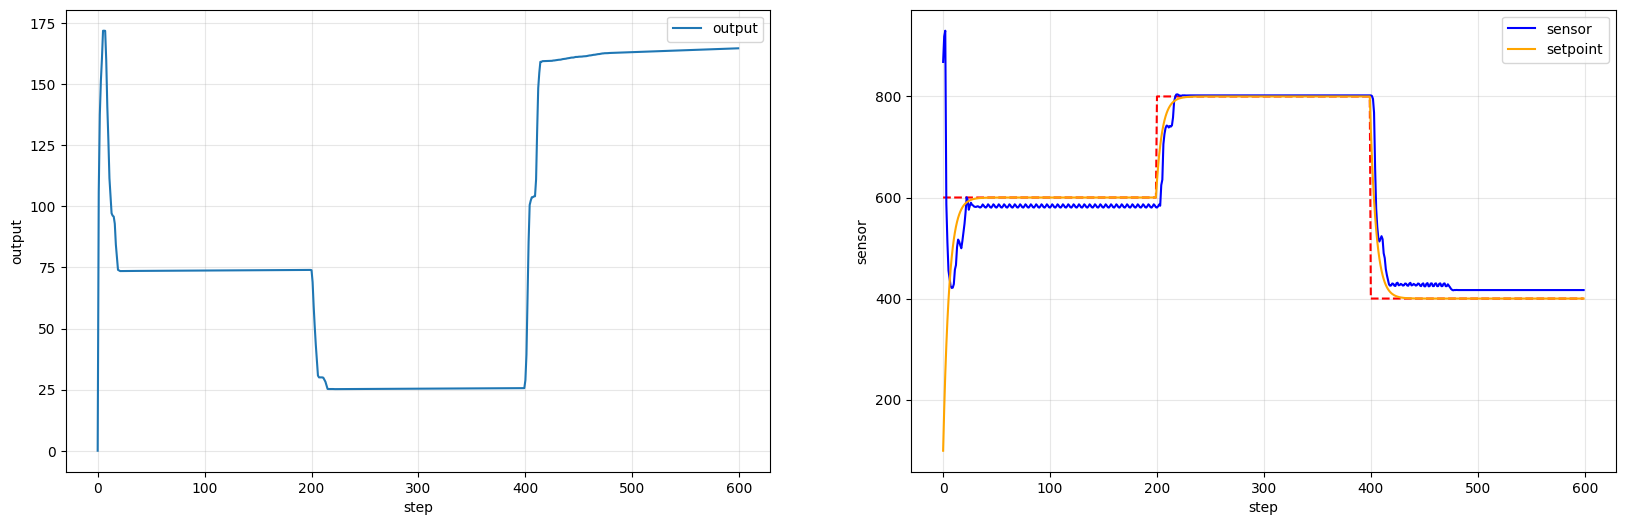

,setpoint,ref,u,x,error
0,600,98.837873,0.000000,868.284000,-268.284000
1,600,181.394204,105.798781,918.949392,-318.949392
2,600,250.351049,137.540550,930.080000,-330.080000
3,600,307.948646,151.447053,586.793375,13.206625
4,600,356.058204,160.570582,511.180509,88.819491
...,...,...,...,...,...
595,400,400.000000,164.622298,416.812451,-16.812451
596,400,400.000000,164.638183,416.812451,-16.812451
597,400,400.000000,164.654069,416.812451,-16.812451
598,400,400.000000,164.669955,416.812451,-16.812451


In [65]:
system     = System(sys,     sys_variables, N_STATES_SYS)          
controller = Controller(ctl, ctl_variables, N_STATES_CTL)

setpointPath = [600]*200 + [800]*200 + [400]*200
history = []
x   = 0
ref = 0
ts  = 1.0
alpha = math.exp(-4 * (dt / ts))


for setpoint in setpointPath:
    ref = alpha * ref + (1 - alpha) * setpoint
    u = controller.update(ref, x)
    x = system.update(u)
    history.append({'setpoint': setpoint, 'ref': ref, 'u': u, 'x': x, 'error': setpoint - x})


history = pd.DataFrame(history)
plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
plt.plot(history.u, label='output')
plt.xlabel('step'); plt.ylabel('output'); plt.legend()
plt.grid(alpha=.3)

plt.subplot(1, 2, 2)
plt.plot(history.setpoint, linestyle='--', color='red')
plt.plot(history.x, label='sensor', color='blue')
plt.plot(history.ref, label='setpoint', color='orange')
plt.xlabel('step'); plt.ylabel('sensor')
plt.grid(alpha=.3); plt.legend()

plt.show()
display(history)